In [20]:
if !@isdefined(CBOFSData)
    println("Loading modules and packages...")
    include("../src/cbdata.jl")
    include("../src/ASVGeometry.jl")
    include("../src/clarity.jl")
    include("../src/IVESim.jl")
    include("../src/ntfy.jl")

    using .CBOFSData, .ASVGeometry, .Clarity, .IVESim, .Notify
    using Dates, Statistics, Plots, JuMP, Ipopt, ProgressMeter, JLD2, DataFrames
    
    # Optional: If you are actively editing cbdata.jl, ASVGeometry.jl, etc. 
    # you can use Revise to automatically track changes without re-including!
    using Revise
end


In [75]:
# Plot Settings
plot_font = "Computer Modern"
default(
    fontfamily=plot_font,
    linewidth=2,
    guidefontsize=14,
    tickfontsize=14,
    legendfontsize=10,
    titlefontsize=18
)

In [22]:
frames = discover_files("./datafiles")

120-element Vector{CBOFSFrame}:
 CBOFSFrame("./datafiles\\chesapeake_salinity_20260216_t00z_n001.nc", DateTime("2026-02-16T01:00:00"))
 CBOFSFrame("./datafiles\\chesapeake_salinity_20260216_t00z_n002.nc", DateTime("2026-02-16T02:00:00"))
 CBOFSFrame("./datafiles\\chesapeake_salinity_20260216_t00z_n003.nc", DateTime("2026-02-16T03:00:00"))
 CBOFSFrame("./datafiles\\chesapeake_salinity_20260216_t00z_n004.nc", DateTime("2026-02-16T04:00:00"))
 CBOFSFrame("./datafiles\\chesapeake_salinity_20260216_t00z_n005.nc", DateTime("2026-02-16T05:00:00"))
 CBOFSFrame("./datafiles\\chesapeake_salinity_20260216_t00z_n006.nc", DateTime("2026-02-16T06:00:00"))
 CBOFSFrame("./datafiles\\chesapeake_salinity_20260216_t06z_n001.nc", DateTime("2026-02-16T07:00:00"))
 CBOFSFrame("./datafiles\\chesapeake_salinity_20260216_t06z_n002.nc", DateTime("2026-02-16T08:00:00"))
 CBOFSFrame("./datafiles\\chesapeake_salinity_20260216_t06z_n003.nc", DateTime("2026-02-16T09:00:00"))
 CBOFSFrame("./datafiles\\chesapeake_sali

In [108]:
# datafile_variable = "2026-03-31_121037_static_sim_results.jld2"
# datafile_const = "2026-03-31_121121_const_speed_static_sim_results.jld2"
# datafile_variable = "2026-03-31_122253_static_sim_results.jld2"
# datafile_const = "2026-03-31_122335_const_speed_static_sim_results.jld2"
datafile_variable = "2026-03-31_151349_dynamic_opt_sim.jld2"
datafile_const = "2026-03-31_151403_dynamic_const_sim.jld2"
results_variable = load(datafile_variable)
results_const = load(datafile_const)

Dict{String, Any} with 7 entries:
  "weights_history"    => [1.0 1.0 … 0.522936 0.522936; 1.0 1.0 … 0.49108 0.491…
  "clarity_history"    => [0.229567 0.368732 … 0.601689 0.614414; 0.211014 0.34…
  "lap_hist"           => [1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  5, 5, 5, 5, 5, 5, 5…
  "speed_hist"         => [1.75, 1.75, 1.75, 1.75, 1.75, 1.75, 1.75, 1.75, 1.75…
  "salinity_meas_hist" => [26.0312, 25.9126, 25.9126, 25.9126, 25.9126, 25.9126…
  "lat_hist"           => [36.975, 36.9759, 36.9769, 36.9778, 36.9788, 36.9797,…
  "lon_hist"           => [-76.015, -76.015, -76.015, -76.015, -76.015, -76.015…

In [109]:
println("=== OPTIMIZED SIMULATION RESULTS ===")
total_clarity_variable = sum(results_variable["weights_history"] .* results_variable["clarity_history"])
println("Total Accumulated Clarity (All Time): ", round(total_clarity_variable, digits=2))

total_laps = results_variable["lap_hist"][end]
lap_clarity = zeros(Float64, total_laps)

for lap in 1:total_laps
    idx_for_lap = findall(x -> x == lap, results_variable["lap_hist"])
    lap_clarity[lap] = sum(results_variable["clarity_history"][:, idx_for_lap])
    println("Lap $lap Total Clarity: ", round(lap_clarity[lap], digits=2))
end

target_salinity = 30.0
salinity_deviation = results_variable["salinity_meas_hist"] .- target_salinity

println("Mean Salinity Deviation: ", round(mean(salinity_deviation), digits=2), " PSU")
println("Standard Deviation of Salinity Deviation: ", round(std(salinity_deviation), digits=2), " PSU")

println("\n=== CONSTANT-SPEED SIMULATION RESULTS ===")
total_clarity_const = sum(results_const["weights_history"] .* results_const["clarity_history"])
println("Total Accumulated Clarity (All Time): ", round(total_clarity_const, digits=2))
lap_clarity_const = zeros(Float64, total_laps)
for lap in 1:total_laps
    idx_for_lap_const = findall(x -> x == lap, results_const["lap_hist"])
    lap_clarity_const[lap] = sum(results_const["clarity_history"][:, idx_for_lap_const])
    println("Lap $lap Total Clarity: ", round(lap_clarity_const[lap], digits=2))
end

println("Mean Salinity Deviation: ", round(mean(results_const["salinity_meas_hist"] .- target_salinity), digits=2), " PSU")
println("Standard Deviation of Salinity Deviation: ", round(std(results_const["salinity_meas_hist"] .- target_salinity), digits=2), " PSU")


println("\n=== COMPARISON SUMMARY ===")
println("Total Accumulated Clarity (Optimized): ", round(total_clarity_variable, digits=2))
println("Total Accumulated Clarity (Constant-Speed): ", round(total_clarity_const, digits=2))
println("Difference (Optimized - Constant): ", round(total_clarity_variable - total_clarity_const, digits=2))
println("Percent Improvement: ", round(100 * (total_clarity_variable - total_clarity_const) / abs(total_clarity_const), digits=2), "%")


=== OPTIMIZED SIMULATION RESULTS ===
Total Accumulated Clarity (All Time): 33354.83
Lap 1 Total Clarity: 10686.3
Lap 2 Total Clarity: 13754.65
Lap 3 Total Clarity: 14462.77
Lap 4 Total Clarity: 12519.73
Mean Salinity Deviation: -1.56 PSU
Standard Deviation of Salinity Deviation: 2.82 PSU

=== CONSTANT-SPEED SIMULATION RESULTS ===
Total Accumulated Clarity (All Time): 24206.58
Lap 1 Total Clarity: 10683.76
Lap 2 Total Clarity: 10738.96
Lap 3 Total Clarity: 10738.95
Lap 4 Total Clarity: 10738.96
Mean Salinity Deviation: -2.58 PSU
Standard Deviation of Salinity Deviation: 2.33 PSU

=== COMPARISON SUMMARY ===
Total Accumulated Clarity (Optimized): 33354.83
Total Accumulated Clarity (Constant-Speed): 24206.58
Difference (Optimized - Constant): 9148.25
Percent Improvement: 37.79%


In [110]:
# --- 1. Fix Setup & Extract Global Variables ---
# Use size(..., 1) instead of length()!
npts = size(results_variable["clarity_history"], 1)
first_frame = frames[25]
lon_v_static, lat_v_static, salt_v_static = load_surface_salinity(first_frame.file)

lon_path, lat_path, s_vec = discretize_polyline(transect_lon_shifted, transect_lat_shifted, npts)

# Reconstruct relative time in hours for cleaner plots
nsteps = length(results_variable["speed_hist"])
dt_step_sec = 60.0
time_hours = (0:nsteps-1) .* (dt_step_sec / 3600.0)

# Reconstruct Absolute Time for the Animation
sim_times = collect(frames[1].dt : Minute(1) : frames[1].dt + Minute(nsteps-1))
@assert nsteps > 0 "No simulation history found."
# sim_times_noyr = Dates.format.(sim_times, dateformat"mm-dd");

In [116]:
# --- 2. Optimized Run: Speed / Weight Overlay ---
speed_hist_opt = results_variable["speed_hist"]
lon_hist_opt = results_variable["lon_hist"]
lat_hist_opt = results_variable["lat_hist"]
weights_hist_opt = results_variable["weights_history"]

weight_at_robot_opt = zeros(Float64, nsteps)

for k in 1:nsteps
    d2 = (lon_path .- lon_hist_opt[k]).^2 .+ (lat_path .- lat_hist_opt[k]).^2
    idx = argmin(d2)
    weight_at_robot_opt[k] = weights_hist_opt[idx, k]
end


p_speed = plot(
    sim_times, speed_hist_opt;
    lc = :black, ls=:dash,
    ylabel = "Speed (m/s)",
    title = "Optimized Speed & Observed Weight Over Time",
    grid = true,
    legend = false,
    ylims = (0, maximum(speed_hist_opt)*1.1)
)

p_weight = plot(
    sim_times, weight_at_robot_opt;
    lc = :black, ls = :dash, grid = true,
    xlabel = "Simulation Time (Date in 2026)",
    ylabel = "Weight at Robot Location",
    legend=false
)
plot(p_speed, p_weight; layout = (2,1), link=:x,size=(800,600), margin=6Plots.mm, left_margin=6Plots.mm, right_margin=10Plots.mm)
plot!(dpi=1200)
savefig("temp_figs/post_opt_speed_weight_overlay.pdf")
plot!()

In [117]:
# --- 3. Constant Run: Speed / Weight Overlay ---
speed_hist_const = results_const["speed_hist"]
lon_hist_const = results_const["lon_hist"]
lat_hist_const = results_const["lat_hist"]
weights_hist_const = results_const["weights_history"]

weight_at_robot_const = zeros(Float64, nsteps)

for k in 1:nsteps
    d2 = (lon_path .- lon_hist_const[k]).^2 .+ (lat_path .- lat_hist_const[k]).^2
    idx = argmin(d2)
    weight_at_robot_const[k] = weights_hist_const[idx, k]
end

p_speed_const = plot(
    sim_times, speed_hist_const;
    lc = :black, ls = :dash,
    ylabel = "Speed (m/s)",
    title = "Constant Speed & Observed Weight Over Time",
    grid = true,
    legend = false,
    ylims = (0, maximum(speed_hist_const) * 1.1)
)

p_weight_const = plot(
    sim_times, weight_at_robot_const;
    lc = :black, ls = :dash, grid = true,
    xlabel = "Simulation Time (Date in 2026)",
    ylabel = "Weight at Robot Location",
    legend = false
)

plot(
    p_speed_const, p_weight_const;
    layout = (2, 1), link = :x, size = (800, 600),
    margin = 6Plots.mm, left_margin = 6Plots.mm, right_margin = 10Plots.mm
)
plot!(dpi = 1200)
savefig("temp_figs/post_const_speed_weight_overlay.pdf")
plot!()

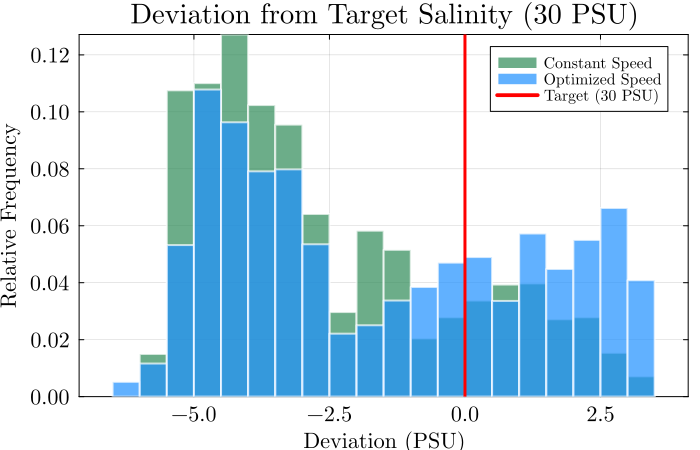

"c:\\Users\\kavin\\OneDrive\\Research\\CPS\\cdc26_ive_intro\\code\\chesapeake_bay\\post_salinity_deviation_comparison.png"

In [113]:
# --- 4. Combined Histogram ---
# Overlays both runs onto the same plot to show how much tighter the variance is on the optimized run
target_salinity = 30.0
sal_dev_opt = results_variable["salinity_meas_hist"] .- target_salinity
sal_dev_const = results_const["salinity_meas_hist"] .- target_salinity

p_hist = histogram(
    [sal_dev_const, sal_dev_opt],
    labels = ["Constant Speed" "Optimized Speed"],
    color = [:seagreen :dodgerblue],
    bins = 40,
    normalize = :probability,
    title = "Deviation from Target Salinity (30 PSU)",
    xlabel = "Deviation (PSU)",
    ylabel = "Relative Frequency",
    linecolor = :white,
    alpha = 0.7,
    grid = true,
    framestyle = :box,
    size = (700, 450)
)
vline!(p_hist, [0.0], lw=3, color=:red, label="Target (30 PSU)")
display(p_hist)
savefig("post_salinity_deviation_comparison.png")

In [119]:
# --- 5. Generate MP4 Animation for Optimized Run (Time-Varying Environment) ---

# Helper to map the exact simulation time to the closest available environmental frame
frame_times = [fr.dt for fr in frames]
frame_idx_for_time(t) = argmin(abs.(Dates.value.(frame_times .- t)))

frame_stride = max(1, fld(nsteps, 300))
frame_ids = 1:frame_stride:nsteps

lat_min, lat_max = 36.75, 37.5
lon_pad, lat_pad = 0.02, 0.02
xlims_map = (minimum(lon_path) - lon_pad, maximum(lon_path) + lon_pad)
ylims_map = (lat_min - lat_pad, lat_max + lat_pad)

sal_meas_opt = results_variable["salinity_meas_hist"]
smin, smax = minimum(sal_meas_opt), maximum(sal_meas_opt)
spad = max(0.5, 0.05 * max(smax - smin, eps()))

clarity_hist_opt = results_variable["clarity_history"]
lap_hist_opt = results_variable["lap_hist"]

# Cache salinity fields by file path to avoid repeated I/O
sal_cache = Dict{String, Tuple{Vector{Float64}, Vector{Float64}, Vector{Float64}}}()

l = @layout [a b; c]

println("Building Optimized Run Animation (Dynamic Environment)...")
anim_opt = @animate for k in frame_ids
    lon_r, lat_r = lon_hist_opt[k], lat_hist_opt[k]
    tr_lon, tr_lat = lon_hist_opt[1:k], lat_hist_opt[1:k]

    # 1. Find the closest environmental frame for the current simulation time
    fr = frames[frame_idx_for_time(sim_times[k])]
    
    # 2. Load from cache or read the file
    if !haskey(sal_cache, fr.file)
        sal_cache[fr.file] = load_surface_salinity(fr.file)
    end
    lon_v, lat_v, salt_v = sal_cache[fr.file]

    # 3. Filter points to ROI for faster plotting
    roi = (lon_v .>= xlims_map[1]) .& (lon_v .<= xlims_map[2]) .&
          (lat_v .>= ylims_map[1]) .& (lat_v .<= ylims_map[2])
    idx = findall(roi)
    
    if length(idx) > 12000
        step_val = cld(length(idx), 12000)
        idx = idx[1:step_val:end]
    end

    p1 = scatter(
        lon_v[idx], lat_v[idx];
        marker_z = salt_v[idx],
        m = (2.0, :square, stroke(0)),
        c = :viridis, clims = (0, 35),
        colorbar = true, colorbar_title = "Salinity (PSU)",
        xlabel = "Longitude", ylabel = "Latitude",
        title = "Boat + Salinity\n$(Dates.format(sim_times[k], dateformat"yyyy-mm-dd HH:MM")) UTC | Lap $(lap_hist_opt[k])",
        aspect_ratio = :equal, xlims = xlims_map, ylims = ylims_map,
        framestyle = :box, grid = true, legend = :bottomleft
    )
    plot!(p1, transect_lon_shifted, transect_lat_shifted; lw = 2.5, lc = :white, label = "Planned Path")
    plot!(p1, tr_lon, tr_lat; lw = 2, lc = :dodgerblue, label = "Track")
    scatter!(p1, [lon_r], [lat_r]; ms = 6, mc = :red, label = "Boat")

    p2 = plot(
        lon_path, lat_path;
        line_z = clarity_hist_opt[:, k],
        linewidth = 6,
        c = :plasma, clims = (0, 1),
        colorbar = true, colorbar_title = "Clarity",
        xlabel = "Longitude", ylabel = "Latitude",
        title = "Clarity Map (Optimized Speed)",
        aspect_ratio = :equal, xlims = xlims_map, ylims = ylims_map,
        legend = false, framestyle = :box, grid = true
    )
    scatter!(p2, [lon_r], [lat_r]; ms = 6, mc = :white, msw = 0, label = false)

    p3 = plot(
        time_hours[1:k], sal_meas_opt[1:k];
        lw = 2.5, lc = :darkorange,
        xlabel = "Time (Hours)", ylabel = "Measured Salinity (PSU)",
        title = "Measured Salinity vs Time",
        ylims = (smin - spad, smax + spad),
        xlims = (0, time_hours[end]),
        legend = :topright, framestyle = :box, grid = true,
        label = "Measured"
    )
    hline!(p3, [target_salinity]; lc = :red, ls = :dash, lw = 1.5, label = "Target")

    plot(p1, p2, p3; layout = l, size = (1400, 900))
end

mp4(anim_opt, "optimized_dynamic_env_results.mp4"; fps = 15)

Building Optimized Run Animation (Dynamic Environment)...


[ Info: Saved animation to c:\Users\kavin\OneDrive\Research\CPS\cdc26_ive_intro\code\chesapeake_bay\optimized_dynamic_env_results.mp4


Plots.AnimatedGif("c:\\Users\\kavin\\OneDrive\\Research\\CPS\\cdc26_ive_intro\\code\\chesapeake_bay\\optimized_dynamic_env_results.mp4")